In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)
%matplotlib inline


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/opt/sw/anaconda3/2023.09/lib/python3.11/runpy.py", line 198, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/opt/sw/anaconda3/2023.09/lib/python3.11/runpy.py", line 88, in _run_code
    exec(code, run_globals)
  File "/opt/sw/anaconda3/2023.09/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/opt/sw/anaconda3/2023.09/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/opt/sw/anaconda3/2023.09/lib/python3.11/runpy.py", line 198, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/opt/sw/anaconda3/2023.09/lib/python3.11/runpy.py", line 88, in _run_code
    exec(code, run_globals)
  File "/opt/sw/anaconda3/2023.09/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/opt/sw/anaconda3/2023.09/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start

AttributeError: _ARRAY_API not found

In [2]:
url = 'https://www.ncei.noaa.gov/data/international-best-track-archive-for-climate-stewardship-ibtracs/v04r00/access/csv/ibtracs.ALL.list.v04r00.csv'

df = pd.read_csv(url, parse_dates=['ISO_TIME'], usecols=range(12),
                 skiprows=[1], na_values=[' ', 'NOT_NAMED'],
                 keep_default_na=False, dtype={'NAME': str})
df.tail()

,SID,SEASON,NUMBER,BASIN,SUBBASIN,NAME,ISO_TIME,NATURE,LAT,LON,WMO_WIND,WMO_PRES
716160,2024147N19089,2024,27,NI,BB,REMAL,2024-05-27 06:00:00,NR,23.0325,89.3509,NaN,NaN
716161,2024147N19089,2024,27,NI,BB,REMAL,2024-05-27 09:00:00,NR,23.3337,89.6178,NaN,NaN
716162,2024147N19089,2024,27,NI,BB,REMAL,2024-05-27 12:00:00,NR,23.6263,89.8799,NaN,NaN
716163,2024147N19089,2024,27,NI,BB,REMAL,2024-05-27 15:00:00,NR,23.9143,90.1400,NaN,NaN
716164,2024147N19089,2024,27,NI,BB,REMAL,2024-05-27 18:00:00,NR,24.2000,90.4000,NaN,NaN


In [3]:
print(f"Total rows: {len(df):,}")

Total rows: 716,165


In [4]:
na_df = df[df['BASIN'] == 'NA']
print(f"Unique North Atlantic hurricanes (by SID): {na_df['SID'].nunique():,}")

Unique North Atlantic hurricanes (by SID): 2,344


In [5]:
for col in ['BASIN', 'SUBBASIN', 'NATURE']:
    print(f"\n{col}:")
    print(df[col].unique())


BASIN:
['NI' 'SI' 'NA' 'EP' 'WP' 'SP' 'SA']

SUBBASIN:
['BB' 'AS' 'MM' 'GM' 'NA' 'CS' 'WA' 'EA' 'CP']

NATURE:
['NR' 'TS' 'ET' 'SS' 'MX' 'DS']


In [6]:
df = df.rename(columns={'WMO_WIND': 'WIND', 'WMO_PRES': 'PRES'})
df.columns

Index(['SID', 'SEASON', 'NUMBER', 'BASIN', 'SUBBASIN', 'NAME', 'ISO_TIME', 'NATURE', 'LAT', 'LON', 'WIND', 'PRES'], dtype='object')

In [7]:
df.nlargest(10, 'WIND')[['SID', 'NAME', 'BASIN', 'ISO_TIME', 'WIND', 'PRES']]

,SID,NAME,BASIN,ISO_TIME,WIND,PRES
666142,2015293N13266,PATRICIA,EP,2015-10-23 12:00:00,185.0,872.0
666140,2015293N13266,PATRICIA,EP,2015-10-23 06:00:00,180.0,886.0
666144,2015293N13266,PATRICIA,EP,2015-10-23 18:00:00,180.0,878.0
427655,1980214N11330,ALLEN,NA,1980-08-07 18:00:00,165.0,899.0
178210,1935241N23291,NaN,NA,1935-09-03 00:00:00,160.0,892.0
178211,1935241N23291,NaN,NA,1935-09-03 02:00:00,160.0,892.0
178213,1935241N23291,NaN,NA,1935-09-03 06:00:00,160.0,NaN
482093,1988253N12306,GILBERT,NA,1988-09-14 00:00:00,160.0,888.0
552477,1997253N12255,LINDA,EP,1997-09-12 06:00:00,160.0,902.0
605764,2005289N18282,WILMA,NA,2005-10-19 12:00:00,160.0,882.0


In [8]:
grouped = df.groupby('SID').agg(
    NAME=('NAME', 'first'),
    BASIN=('BASIN', 'first'),
    SEASON=('SEASON', 'first'),
    MAX_WIND=('WIND', 'max'),
    MIN_PRES=('PRES', 'min')
).reset_index()

grouped.nlargest(10, 'MAX_WIND')

,SID,NAME,BASIN,SEASON,MAX_WIND,MIN_PRES
12921,2015293N13266,PATRICIA,EP,2015,185.0,872.0
9087,1980214N11330,ALLEN,NA,1980,165.0,899.0
4105,1935241N23291,None,NA,1935,160.0,892.0
10011,1988253N12306,GILBERT,NA,1988,160.0,888.0
11066,1997253N12255,LINDA,EP,1997,160.0,902.0
11943,2005289N18282,WILMA,NA,2005,160.0,882.0
13310,2019236N10314,DORIAN,NA,2019,160.0,910.0
11189,1998295N12284,MITCH,NA,1998,155.0,905.0
11926,2005261N21290,RITA,NA,2005,155.0,895.0
12337,2009288N07267,RICK,EP,2009,155.0,906.0


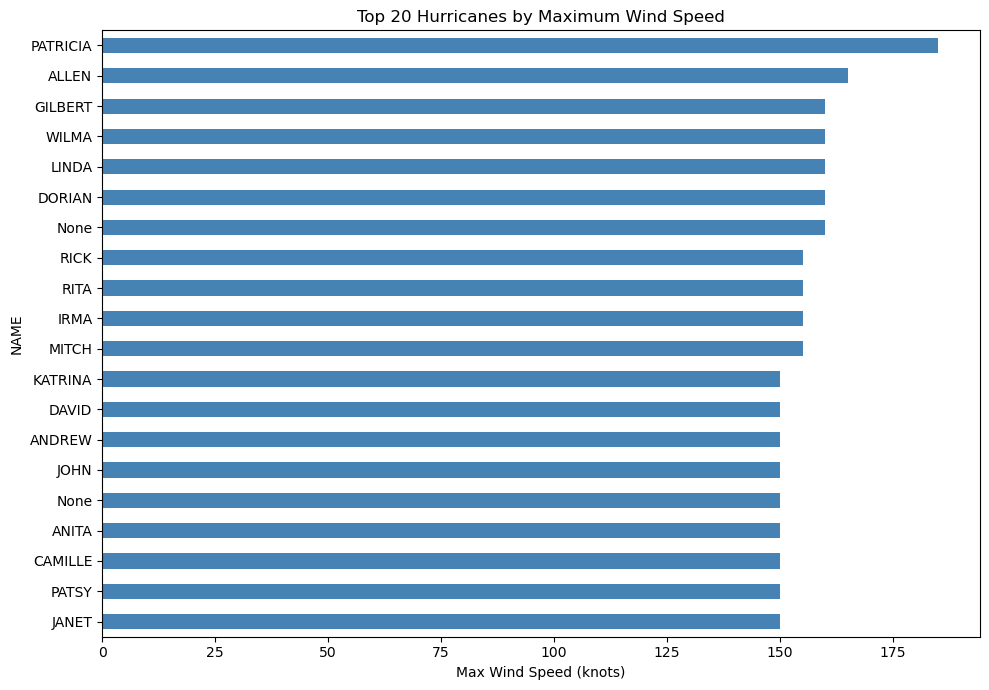

In [9]:
top20 = grouped.nlargest(20, 'MAX_WIND').sort_values('MAX_WIND')

fig, ax = plt.subplots(figsize=(10, 7))
top20.plot.barh(x='NAME', y='MAX_WIND', ax=ax, legend=False, color='steelblue')
ax.set_xlabel('Max Wind Speed (knots)')
ax.set_title('Top 20 Hurricanes by Maximum Wind Speed')
plt.tight_layout()
plt.show()

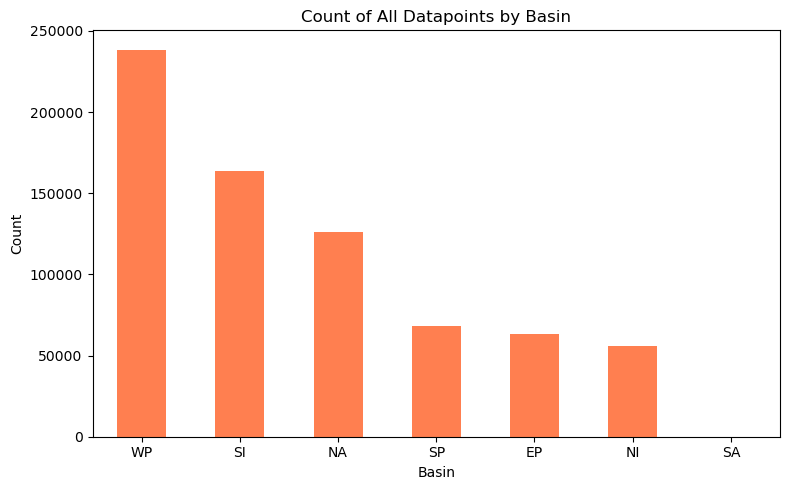

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
df['BASIN'].value_counts().plot.bar(ax=ax, color='coral')
ax.set_xlabel('Basin')
ax.set_ylabel('Count')
ax.set_title('Count of All Datapoints by Basin')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

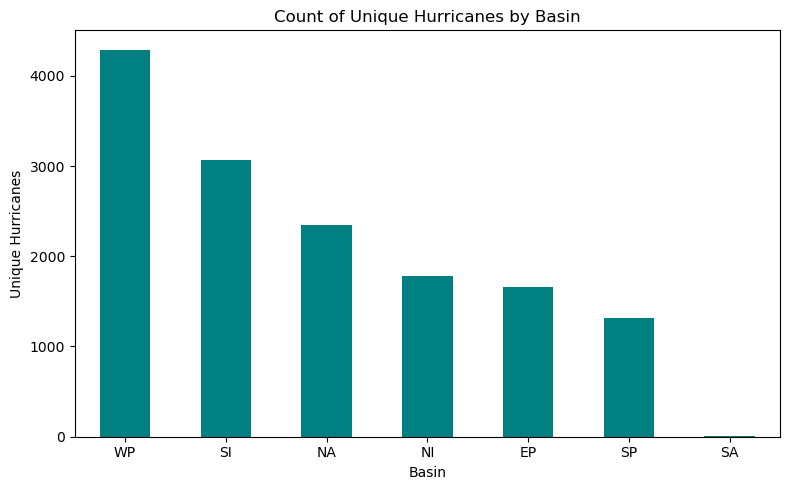

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
df.groupby('BASIN')['SID'].nunique().sort_values(ascending=False).plot.bar(ax=ax, color='teal')
ax.set_xlabel('Basin')
ax.set_ylabel('Unique Hurricanes')
ax.set_title('Count of Unique Hurricanes by Basin')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

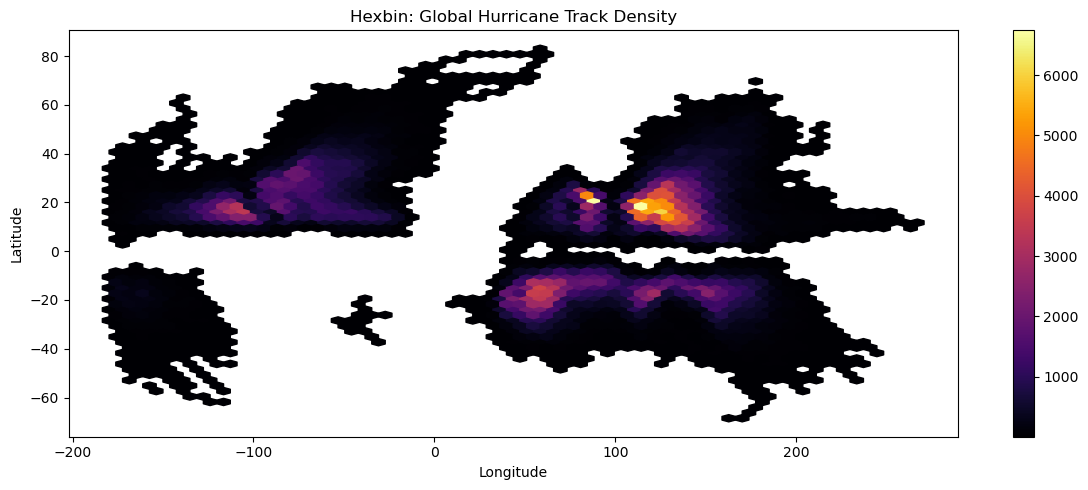

In [12]:
valid = df.dropna(subset=['LAT', 'LON'])

fig, ax = plt.subplots(figsize=(12, 5))
valid.plot.hexbin(x='LON', y='LAT', gridsize=60, cmap='inferno', mincnt=1, ax=ax)
ax.set_title('Hexbin: Global Hurricane Track Density')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

In [13]:
katrina = df[(df['NAME'] == 'KATRINA') & (df['SEASON'] == 2005)]
katrina_sid = katrina['SID'].values[0]
print(f"Katrina SID: {katrina_sid}")

Katrina SID: 2005236N23285


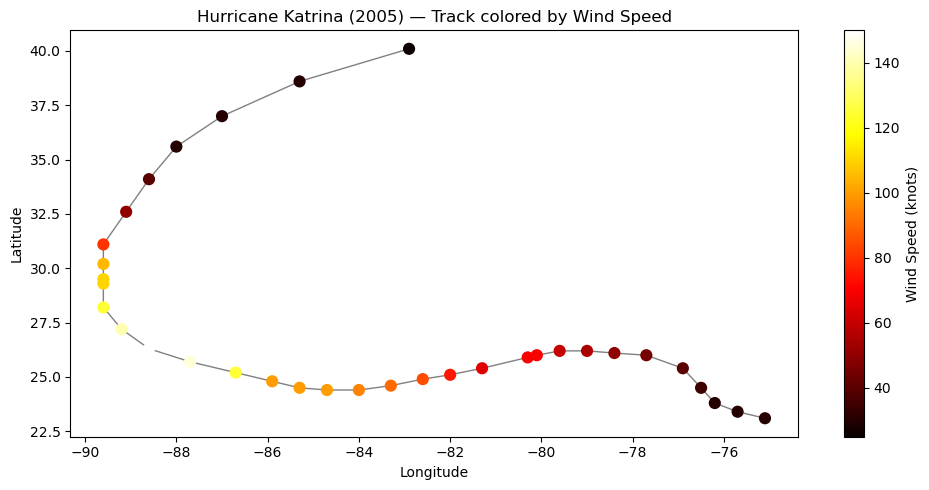

In [14]:
kat = df[df['SID'] == katrina_sid].dropna(subset=['LAT', 'LON', 'WIND'])

fig, ax = plt.subplots(figsize=(10, 5))
sc = ax.scatter(kat['LON'], kat['LAT'], c=kat['WIND'], cmap='hot', s=60, zorder=3)
ax.plot(kat['LON'], kat['LAT'], color='gray', linewidth=1, zorder=2)
plt.colorbar(sc, ax=ax, label='Wind Speed (knots)')
ax.set_title('Hurricane Katrina (2005) — Track colored by Wind Speed')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

In [15]:
df = df.set_index('ISO_TIME')
df.head()

,SID,SEASON,NUMBER,BASIN,SUBBASIN,NAME,NATURE,LAT,LON,WIND,PRES
ISO_TIME,,,,,,,,,,,
1842-10-25 03:00:00,1842298N11080,1842,1,NI,BB,NaN,NR,10.9000,80.3000,NaN,NaN
1842-10-25 06:00:00,1842298N11080,1842,1,NI,BB,NaN,NR,10.8709,79.8265,NaN,NaN
1842-10-25 09:00:00,1842298N11080,1842,1,NI,BB,NaN,NR,10.8431,79.3524,NaN,NaN
1842-10-25 12:00:00,1842298N11080,1842,1,NI,BB,NaN,NR,10.8188,78.8772,NaN,NaN
1842-10-25 15:00:00,1842298N11080,1842,1,NI,BB,NaN,NR,10.8000,78.4000,NaN,NaN


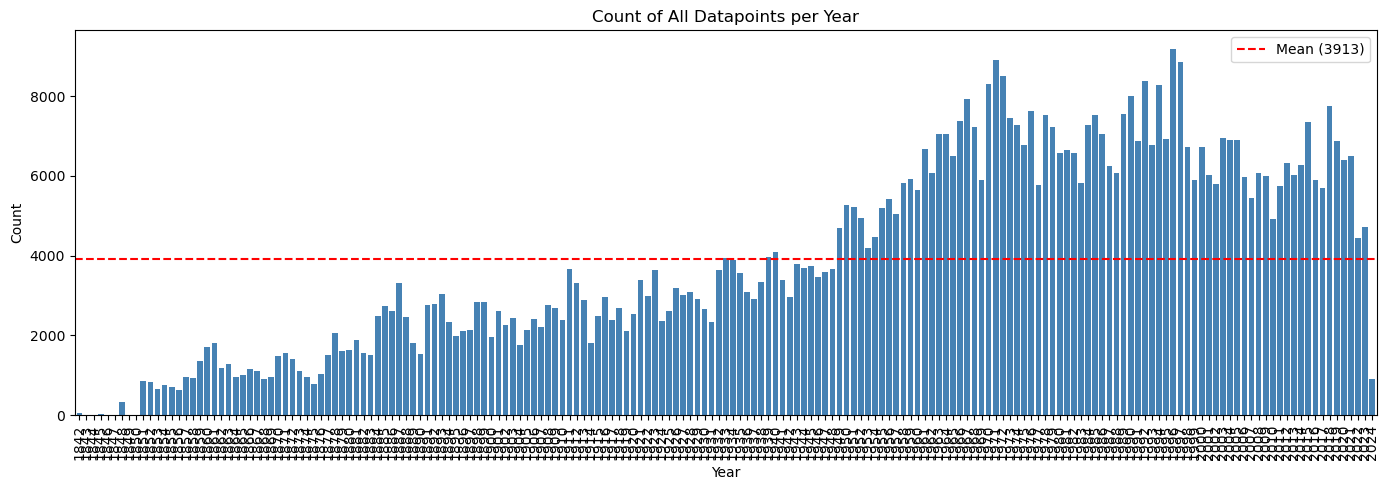

High activity years:
ISO_TIME
1967    7934
1970    8295
1971    8911
1972    8503
1976    7634
1990    7996
1992    8389
1994    8271
1996    9189
1997    8854
2018    7763
dtype: int64

Low activity years:
ISO_TIME
1842    65
1843     0
1844     0
1845    25
1846     0
1847     0
1849     0
1850     0
dtype: int64


In [16]:
yearly = df.resample('YE').size()
yearly.index = yearly.index.year

fig, ax = plt.subplots(figsize=(14, 5))
yearly.plot(ax=ax, kind='bar', color='steelblue', width=0.8)
ax.axhline(yearly.mean(), color='red', linestyle='--', label=f'Mean ({yearly.mean():.0f})')
ax.set_title('Count of All Datapoints per Year')
ax.set_xlabel('Year')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

# Anomalous years
mean, std = yearly.mean(), yearly.std()
print("High activity years:")
print(yearly[yearly > mean + 1.5*std])
print("\nLow activity years:")
print(yearly[yearly < mean - 1.5*std])